# NextTick - Phase 1: Data Pipeline

## Overview

This notebook builds the complete NextTick dataset used by the classification (Phase 2) and regression (Phase 3) notebooks. It performs four tasks:

1. **Download** raw daily OHLCV data for 50 large-cap US stocks across 8 sectors
2. **Compute per-ticker features** -technical indicators and OHLCV-derived features
3. **Fetch and merge market context features** - broad market, macro, and sector ETF signals
4. **Generate targets and save** - create `target_return` (regression) and `target_direction` (classification)

The output is `data/processed/nexttick_dataset_50tickers.csv`, a long-format table where each row is one `(date, ticker)` observation with all features and targets.

## Universe

50 tickers across 8 sectors:

| Sector | ETF | Count | Tickers |
|---|---|---|---|
| Technology | XLK | 7 | AAPL, MSFT, GOOGL, NVDA, CRM, ORCL, ADBE |
| Consumer Discretionary | XLY | 6 | AMZN, TSLA, HD, NKE, MCD, SBUX |
| Financials | XLF | 6 | JPM, GS, BAC, V, MA, BLK |
| Healthcare | XLV | 7 | JNJ, PFE, UNH, LLY, ABBV, MRK, TMO |
| Energy | XLE | 5 | XOM, CVX, COP, SLB, EOG |
| Industrials | XLI | 6 | CAT, BA, HON, UPS, DE, GE |
| Consumer Staples | XLP | 6 | PG, KO, WMT, COST, PEP, PM |
| Communication Services | XLC | 7 | META, NFLX, DIS, VZ, T, CMCSA, TMUS |

## Date window

Five years of daily data: **2021-04-21 -> 2026-04-21**. All tickers and market instruments share this window.

## Features (21 total)

- **Price / technical (6):** daily_return, sma_10, sma_20, volatility_10, momentum_10, rsi_14
- **Market / macro (10):** spy_return, vix_level, sector_return, relative_to_spy, relative_to_sector, tnx_change, dxy_change, oil_return, day_of_week, month
- **OHLCV-derived (5):** overnight_gap, intraday_return, daily_range_pct, close_location, relative_volume

## Targets

- **`target_return`** - next-day percentage change in closing price (regression target)
- **`target_direction`** - 1 if next-day return is positive, else 0 (classification target)

## 1. Imports and Universe Definition

We define the ticker-to-sector mapping and the list of market instruments to fetch. Each stock ticker is assigned to the sector ETF that best matches its industry classification.

In [20]:
# Standard data stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

# yfinance for market data, pandas_ta for technical indicators (RSI)
import yfinance as yf
import pandas_ta as ta

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Frozen 5-year date window kept constant across every phase of this project
START_DATE = "2021-04-21"
END_DATE   = "2026-04-21"

# Ticker ->sector mapping. 50 tickers across 8 sectors.
# Each stock is mapped to the sector ETF it most naturally belongs to,
# which we'll use later to compute sector-relative features.
TICKER_TO_SECTOR = {
    # Technology (XLK) - 7 tickers
    "AAPL": "XLK", "MSFT": "XLK", "GOOGL": "XLK", "NVDA": "XLK",
    "CRM":  "XLK", "ORCL": "XLK", "ADBE": "XLK",
    # Consumer Discretionary (XLY) - 6 tickers 
    "AMZN": "XLY", "TSLA": "XLY", "HD":   "XLY", "NKE":  "XLY",
    "MCD":  "XLY", "SBUX": "XLY",
    # Financials (XLF) - 6 tickers
    "JPM":  "XLF", "GS":   "XLF", "BAC":  "XLF", "V":    "XLF",
    "MA":   "XLF", "BLK":  "XLF",
    # Healthcare (XLV) - 7 tickers
    "JNJ":  "XLV", "PFE":  "XLV", "UNH":  "XLV", "LLY":  "XLV",
    "ABBV": "XLV", "MRK":  "XLV", "TMO":  "XLV",
    # Energy (XLE) - 5 tickers
    "XOM":  "XLE", "CVX":  "XLE", "COP":  "XLE", "SLB":  "XLE",
    "EOG":  "XLE",
    # Industrials (XLI) - 6 tickers
    "CAT":  "XLI", "BA":   "XLI", "HON":  "XLI", "UPS":  "XLI",
    "DE":   "XLI", "GE":   "XLI",
    # Consumer Staples (XLP) - 6 tickers
    "PG":   "XLP", "KO":   "XLP", "WMT":  "XLP", "COST": "XLP",
    "PEP":  "XLP", "PM":   "XLP",
    # Communication Services (XLC) - 7 tickers
    "META": "XLC", "NFLX": "XLC", "DIS":  "XLC", "VZ":   "XLC",
    "T":    "XLC", "CMCSA": "XLC", "TMUS": "XLC",
}

TICKERS = list(TICKER_TO_SECTOR.keys())
SECTORS = sorted(set(TICKER_TO_SECTOR.values()))

MARKET_SYMBOLS = {
    "SPY":       "spy_close",    # Broad US equity market
    "^VIX":      "vix_level",    # Market volatility index (fear gauge)
    "^TNX":      "tnx_level",    # 10-year Treasury yield
    "DX-Y.NYB":  "dxy_level",    # US dollar index
    "USO":       "uso_close",    # Oil proxy (ETF)
    # 8 sector ETFs - one per sector represented in our universe
    "XLK":       "xlk_close",
    "XLY":       "xly_close",
    "XLF":       "xlf_close",
    "XLV":       "xlv_close",
    "XLE":       "xle_close",
    "XLI":       "xli_close",
    "XLP":       "xlp_close",
    "XLC":       "xlc_close",
}

# Print summary for sanity check
print(f"Total tickers: {len(TICKERS)}")
print(f"Total sectors: {len(SECTORS)} - {SECTORS}")
print(f"Market instruments to fetch: {len(MARKET_SYMBOLS)}")
print(f"Date range: {START_DATE} -> {END_DATE}")

# Count tickers per sector and display
sector_counts = pd.Series(TICKER_TO_SECTOR).value_counts().sort_index()
print("\nTickers per sector:")
for sector, count in sector_counts.items():
    tickers_in_sector = [t for t, s in TICKER_TO_SECTOR.items() if s == sector]
    print(f"  {sector}: {count:>2} - {tickers_in_sector}")

Total tickers: 50
Total sectors: 8 - ['XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLV', 'XLY']
Market instruments to fetch: 13
Date range: 2021-04-21 -> 2026-04-21

Tickers per sector:
  XLC:  7 - ['META', 'NFLX', 'DIS', 'VZ', 'T', 'CMCSA', 'TMUS']
  XLE:  5 - ['XOM', 'CVX', 'COP', 'SLB', 'EOG']
  XLF:  6 - ['JPM', 'GS', 'BAC', 'V', 'MA', 'BLK']
  XLI:  6 - ['CAT', 'BA', 'HON', 'UPS', 'DE', 'GE']
  XLK:  7 - ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'CRM', 'ORCL', 'ADBE']
  XLP:  6 - ['PG', 'KO', 'WMT', 'COST', 'PEP', 'PM']
  XLV:  7 - ['JNJ', 'PFE', 'UNH', 'LLY', 'ABBV', 'MRK', 'TMO']
  XLY:  6 - ['AMZN', 'TSLA', 'HD', 'NKE', 'MCD', 'SBUX']


## 2. Fetch Stock OHLCV Data

We download Open, High, Low, Close, Volume for each of the 50 stocks using yfinance. `auto_adjust=True` adjusts prices for splits and dividends, which we want so our returns are clean.

The helper function is defensive: if a ticker returns empty or suspiciously short data, we skip it and log the failure rather than letting a bad download corrupt the rest of the pipeline.

In [21]:
def fetch_stock(ticker, start, end):
    """
    Fetch OHLCV data for a single ticker from yfinance.
    Returns None if the download fails or the data is too short to be useful.
    """
    try:
        # auto_adjust=True adjusts prices for splits and dividends
        df = yf.download(ticker, start=start, end=end, interval="1d",
                         auto_adjust=True, progress=False)
        
        # yfinance sometimes returns multi-index columns; flatten them
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        # Reject empty or suspiciously short responses
        if df.empty or len(df) < 100:
            return None
        
        # Keep only the five columns we need plus a ticker identifier
        df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
        df["ticker"] = ticker
        return df
    except Exception as e:
        print(f"    ERROR fetching {ticker}: {e}")
        return None

print("Fetching stock OHLCV data for 50 tickers...")
print("(yfinance rate-limits - this may take 2-4 minutes)\n")

start_t = time.time()
stock_dfs = []
failed = []

# Loop through all tickers one by one so we can log progress and catch failures per-ticker
for i, ticker in enumerate(TICKERS, 1):
    df = fetch_stock(ticker, START_DATE, END_DATE)
    if df is None:
        print(f"  [{i:>2}/50] {ticker:<6} - FAILED")
        failed.append(ticker)
    else:
        print(f"  [{i:>2}/50] {ticker:<6} - {len(df):>5} rows  ({df.index.min().date()} -> {df.index.max().date()})")
        stock_dfs.append(df)

elapsed = time.time() - start_t
print(f"\nFetch complete in {elapsed:.1f}s")
print(f"Successful: {len(stock_dfs)}/50")
print(f"Failed: {len(failed)}  {failed if failed else ''}")

if failed:
    print("\nSome tickers failed to fetch. The pipeline will proceed without them.")

Fetching stock OHLCV data for 50 tickers...
(yfinance rate-limits - this may take 2-4 minutes)

  [ 1/50] AAPL   -  1255 rows  (2021-04-21 -> 2026-04-20)
  [ 2/50] MSFT   -  1255 rows  (2021-04-21 -> 2026-04-20)
  [ 3/50] GOOGL  -  1255 rows  (2021-04-21 -> 2026-04-20)
  [ 4/50] NVDA   -  1255 rows  (2021-04-21 -> 2026-04-20)
  [ 5/50] CRM    -  1255 rows  (2021-04-21 -> 2026-04-20)
  [ 6/50] ORCL   -  1255 rows  (2021-04-21 -> 2026-04-20)
  [ 7/50] ADBE   -  1255 rows  (2021-04-21 -> 2026-04-20)
  [ 8/50] AMZN   -  1255 rows  (2021-04-21 -> 2026-04-20)
  [ 9/50] TSLA   -  1255 rows  (2021-04-21 -> 2026-04-20)
  [10/50] HD     -  1255 rows  (2021-04-21 -> 2026-04-20)
  [11/50] NKE    -  1255 rows  (2021-04-21 -> 2026-04-20)
  [12/50] MCD    -  1255 rows  (2021-04-21 -> 2026-04-20)
  [13/50] SBUX   -  1255 rows  (2021-04-21 -> 2026-04-20)
  [14/50] JPM    -  1255 rows  (2021-04-21 -> 2026-04-20)
  [15/50] GS     -  1255 rows  (2021-04-21 -> 2026-04-20)
  [16/50] BAC    -  1255 rows  (20

## 3. Compute Per-Ticker Features

For each stock individually, we compute 11 per-ticker features. Doing this per-ticker (rather than on the combined DataFrame) is **critical** - rolling averages and percent changes must not span across different stocks, otherwise we'd contaminate one ticker's signal with another's.

### The 11 per-ticker features

**Price / technical (6):**
- `daily_return` - pct change in close
- `sma_10`, `sma_20` - 10 and 20-day simple moving averages of close
- `volatility_10` - 10-day rolling std of daily returns
- `momentum_10`- 10-day pct change (longer-horizon return)
- `rsi_14` - 14-day Relative Strength Index (momentum oscillator)

**OHLCV-derived (5):**
- `overnight_gap` - open vs prior close, normalized
- `intraday_return` - close vs open, normalized
- `daily_range_pct` - (high - low) / close
- `close_location` - where close sits within the day's range, in [0, 1]
- `relative_volume` - volume vs its own 20-day mean

### Targets

- `target_return` - next-day return (shift daily_return by -1 so it aligns with today's row)
- `target_direction` - 1 if target_return > 0, else 0

In [22]:
# Combine all fetched stocks into one DataFrame for convenience
stocks_df = pd.concat(stock_dfs, axis=0).sort_index()
print(f"Raw combined shape: {stocks_df.shape}")


def add_ticker_features(df_t):
    """
    Compute per-ticker features for a single stock's DataFrame.
    """
    df_t = df_t.sort_index().copy()
    
    # Price / technical features (6) 
    df_t["daily_return"]  = df_t["Close"].pct_change()
    df_t["sma_10"]        = df_t["Close"].rolling(10).mean()
    df_t["sma_20"]        = df_t["Close"].rolling(20).mean()
    df_t["volatility_10"] = df_t["daily_return"].rolling(10).std()
    df_t["momentum_10"]   = df_t["Close"].pct_change(10)
    df_t["rsi_14"]        = ta.rsi(df_t["Close"], length=14)
    
    # OHLCV-derived features (5) 
    # Overnight gap: where today opens relative to yesterday's close
    df_t["overnight_gap"]   = (df_t["Open"] - df_t["Close"].shift(1)) / df_t["Close"].shift(1)
    # Intraday return: close vs open for the same day
    df_t["intraday_return"] = (df_t["Close"] - df_t["Open"]) / df_t["Open"]
    # Range as fraction of close: larger value = more volatile day
    df_t["daily_range_pct"] = (df_t["High"] - df_t["Low"]) / df_t["Close"]
    # Close location: 1.0 means closed at high of day, 0.0 means closed at low
    day_range = df_t["High"] - df_t["Low"]
    df_t["close_location"]  = np.where(day_range > 0,
                                        (df_t["Close"] - df_t["Low"]) / day_range,
                                        0.5)  # If no range (rare), default to 0.5
    # Relative volume: today's volume vs 20-day average
    df_t["relative_volume"] = df_t["Volume"] / df_t["Volume"].rolling(20).mean()
    
    # target_return = next day's daily_return. shift(-1) brings tomorrow's value onto today's row.
    df_t["target_return"]    = df_t["daily_return"].shift(-1)
    # target_direction = 1 if tomorrow is an up day, 0 otherwise
    df_t["target_direction"] = (df_t["target_return"] > 0).astype(int)
    
    return df_t

# Apply feature engineering to each ticker independently, then concatenate
print("Computing per-ticker features...")
feature_dfs = []
for ticker in stocks_df["ticker"].unique():
    df_t = stocks_df[stocks_df["ticker"] == ticker].copy()
    df_t = add_ticker_features(df_t)
    feature_dfs.append(df_t)

stocks_featured = pd.concat(feature_dfs, axis=0).sort_index()
print(f"After per-ticker features: {stocks_featured.shape}")
print(f"NaN counts (before dropna - these come from rolling warmups): {stocks_featured.isna().sum().sum():,}")

Raw combined shape: (62750, 6)
Computing per-ticker features...
After per-ticker features: (62750, 19)
NaN counts (before dropna - these come from rolling warmups): 3,550


## 4. Fetch and Build Market Context Features

We download 13 market instruments, then derive features from them:
- **SPY** -> `spy_return` (broad market return)
- **VIX** -> `vix_level` (used directly as level, not return)
- **TNX** -> `tnx_change` (daily change in 10-year yield)
- **DXY** -> `dxy_change` (dollar index pct change)
- **USO** -> `oil_return` (oil proxy return)
- **8 sector ETFs** -> `xlk_return`, `xly_return`, etc.

In [23]:
def fetch_market_series(symbol, colname, start, end):
    """Fetch a single market instrument and return only its close price as a named Series."""
    df = yf.download(symbol, start=start, end=end, interval="1d",
                     auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df["Close"].rename(colname)


print("Fetching market / sector-ETF data...")
market_series = {}
for symbol, colname in MARKET_SYMBOLS.items():
    try:
        s = fetch_market_series(symbol, colname, START_DATE, END_DATE)
        market_series[colname] = s
        print(f"  {symbol:<10} -> {colname:<12} {len(s):>5} rows")
    except Exception as e:
        print(f"  {symbol:<10} - FAILED: {e}")

# Combine all market series into one DataFrame indexed by date.
market_df = pd.DataFrame(market_series).sort_index().ffill()
print(f"\nMarket DataFrame shape: {market_df.shape}")

mf = pd.DataFrame(index=market_df.index)
mf["spy_return"] = market_df["spy_close"].pct_change()
mf["vix_level"]  = market_df["vix_level"]
mf["tnx_change"] = market_df["tnx_level"].diff()
mf["dxy_change"] = market_df["dxy_level"].pct_change()
mf["oil_return"] = market_df["uso_close"].pct_change()

for sector_etf in ["xlk", "xly", "xlf", "xlv", "xle", "xli", "xlp", "xlc"]:
    mf[f"{sector_etf}_return"] = market_df[f"{sector_etf}_close"].pct_change()

print(f"\nMarket features shape: {mf.shape}")
print(f"Market features: {mf.columns.tolist()}")

Fetching market / sector-ETF data...
  SPY        -> spy_close     1255 rows
  ^VIX       -> vix_level     1255 rows
  ^TNX       -> tnx_level     1255 rows
  DX-Y.NYB   -> dxy_level     1257 rows
  USO        -> uso_close     1255 rows
  XLK        -> xlk_close     1255 rows
  XLY        -> xly_close     1255 rows
  XLF        -> xlf_close     1255 rows
  XLV        -> xlv_close     1255 rows
  XLE        -> xle_close     1255 rows
  XLI        -> xli_close     1255 rows
  XLP        -> xlp_close     1255 rows
  XLC        -> xlc_close     1255 rows

Market DataFrame shape: (1257, 13)

Market features shape: (1257, 13)
Market features: ['spy_return', 'vix_level', 'tnx_change', 'dxy_change', 'oil_return', 'xlk_return', 'xly_return', 'xlf_return', 'xlv_return', 'xle_return', 'xli_return', 'xlp_return', 'xlc_return']


## 5. Join Market Features onto Each Ticker

Now we attach the market features to each stock's rows. 

We also derive two features that compare the stock to the market and to its sector. These tend to be strong features because they isolate stock-specific behavior from broad moves.

Finally we add calendar features (`day_of_week`, `month`) in case there are day-of-week or seasonal effects to learn.

In [24]:
# Map each ticker to its sector's return column name
TICKER_TO_SECTOR_COL = {
    ticker: f"{sector.lower()}_return"
    for ticker, sector in TICKER_TO_SECTOR.items()
}

print("Joining market features per ticker...")

extended_dfs = []
for ticker in stocks_featured["ticker"].unique():
    df_t = stocks_featured[stocks_featured["ticker"] == ticker].copy()
    
    # Look up which sector return column this ticker wants
    sector_col = TICKER_TO_SECTOR_COL[ticker]

    market_slice = mf[["spy_return", "vix_level", "tnx_change", "dxy_change",
                       "oil_return", sector_col]].rename(
        columns={sector_col: "sector_return"}
    )
    df_t = df_t.join(market_slice, how="left")
    
    # Derived relative features
    df_t["relative_to_spy"]    = df_t["daily_return"] - df_t["spy_return"]
    df_t["relative_to_sector"] = df_t["daily_return"] - df_t["sector_return"]
    
    # Calendar features
    df_t["day_of_week"] = df_t.index.dayofweek   # 0=Monday ... 4=Friday
    df_t["month"]       = df_t.index.month        # 1 ... 12
    
    extended_dfs.append(df_t)

df_full = pd.concat(extended_dfs, axis=0).sort_index()
print(f"After market join: {df_full.shape}")

# Drop rows with NaN values. These come from:
#   1. Rolling-window warmup (first 19 rows of each ticker before sma_20 is defined)
#   2. First row of each series (pct_change is NaN)
#   3. Last row of each ticker (target_return requires a 'tomorrow' that doesn't exist)
df_clean = df_full.dropna().copy()
print(f"After dropna: {df_clean.shape}")
print(f"Rows dropped (warmup + endpoints): {len(df_full) - len(df_clean):,}")

Joining market features per ticker...
After market join: (62750, 29)
After dropna: (61750, 29)
Rows dropped (warmup + endpoints): 1,000


## 6. Finalize Feature Set and Run Sanity Checks

We define the final 21-feature list and keep only the columns we need for modeling plus a few identifier/display columns. Then we run sanity checks to catch any data quality issues before saving.

In [25]:
# The 21 features that will be consumed by every downstream model
FEATURE_COLS = [
    # Price / technical (6)
    "daily_return", "sma_10", "sma_20", "volatility_10", "momentum_10", "rsi_14",
    # Market / macro (10)
    "spy_return", "vix_level", "sector_return", "relative_to_spy", "relative_to_sector",
    "tnx_change", "dxy_change", "oil_return", "day_of_week", "month",
    # OHLCV-derived (5)
    "overnight_gap", "intraday_return", "daily_range_pct", "close_location", "relative_volume",
]

assert len(FEATURE_COLS) == 21, f"Expected 21 features, got {len(FEATURE_COLS)}"

# Keep OHLCV columns too
keep_cols = ["Open", "High", "Low", "Close", "Volume", "ticker"] + FEATURE_COLS + ["target_return", "target_direction"]
df_final = df_clean[keep_cols].copy()

print(f"Final dataset shape: {df_final.shape}")
print(f"Feature count: {len(FEATURE_COLS)}")

# check 1: row counts per ticker 
print("\nRows per ticker (sample):")
print(df_final["ticker"].value_counts().head(10))

counts = df_final["ticker"].value_counts()
print(f"\nRow count stats across tickers:")
print(f"  Min: {counts.min()} ({counts.idxmin()})")
print(f"  Max: {counts.max()} ({counts.idxmax()})")
print(f"  Std: {counts.std():.1f}")

# Flag tickers that are meaningfully shorter than the rest
if counts.min() < counts.max() * 0.95:
    print("\n⚠ Some tickers are meaningfully shorter than others - worth investigating.")

Final dataset shape: (61750, 29)
Feature count: 21

Rows per ticker (sample):
ticker
NVDA    1235
GS      1235
ORCL    1235
PEP     1235
UPS     1235
UNH     1235
NKE     1235
META    1235
VZ      1235
MA      1235
Name: count, dtype: int64

Row count stats across tickers:
  Min: 1235 (NVDA)
  Max: 1235 (NVDA)
  Std: 0.0


Feature summary stats:
                        mean       std      min        max
daily_return          0.0006    0.0190  -0.3512     0.3595
sma_10              215.9673  194.6339  11.7964  1157.3700
sma_20              215.5360  194.0687  12.2010  1149.0777
volatility_10         0.0165    0.0095   0.0022     0.1227
momentum_10           0.0056    0.0596  -0.4521     0.4805
rsi_14               52.0346   12.5666   9.1523    94.1953
spy_return            0.0005    0.0108  -0.0585     0.1050
vix_level            19.2476    5.2981  11.8600    52.3300
sector_return         0.0005    0.0128  -0.0920     0.1343
relative_to_spy       0.0000    0.0168  -0.3504     0.3566
relative_to_sector    0.0001    0.0143  -0.3078     0.3414
tnx_change            0.0021    0.0627  -0.3220     0.2100
dxy_change            0.0001    0.0045  -0.0212     0.0165
oil_return            0.0010    0.0223  -0.1166     0.1294
day_of_week           2.0283    1.3981   0.0000     4.0000
month                 6.5854    3

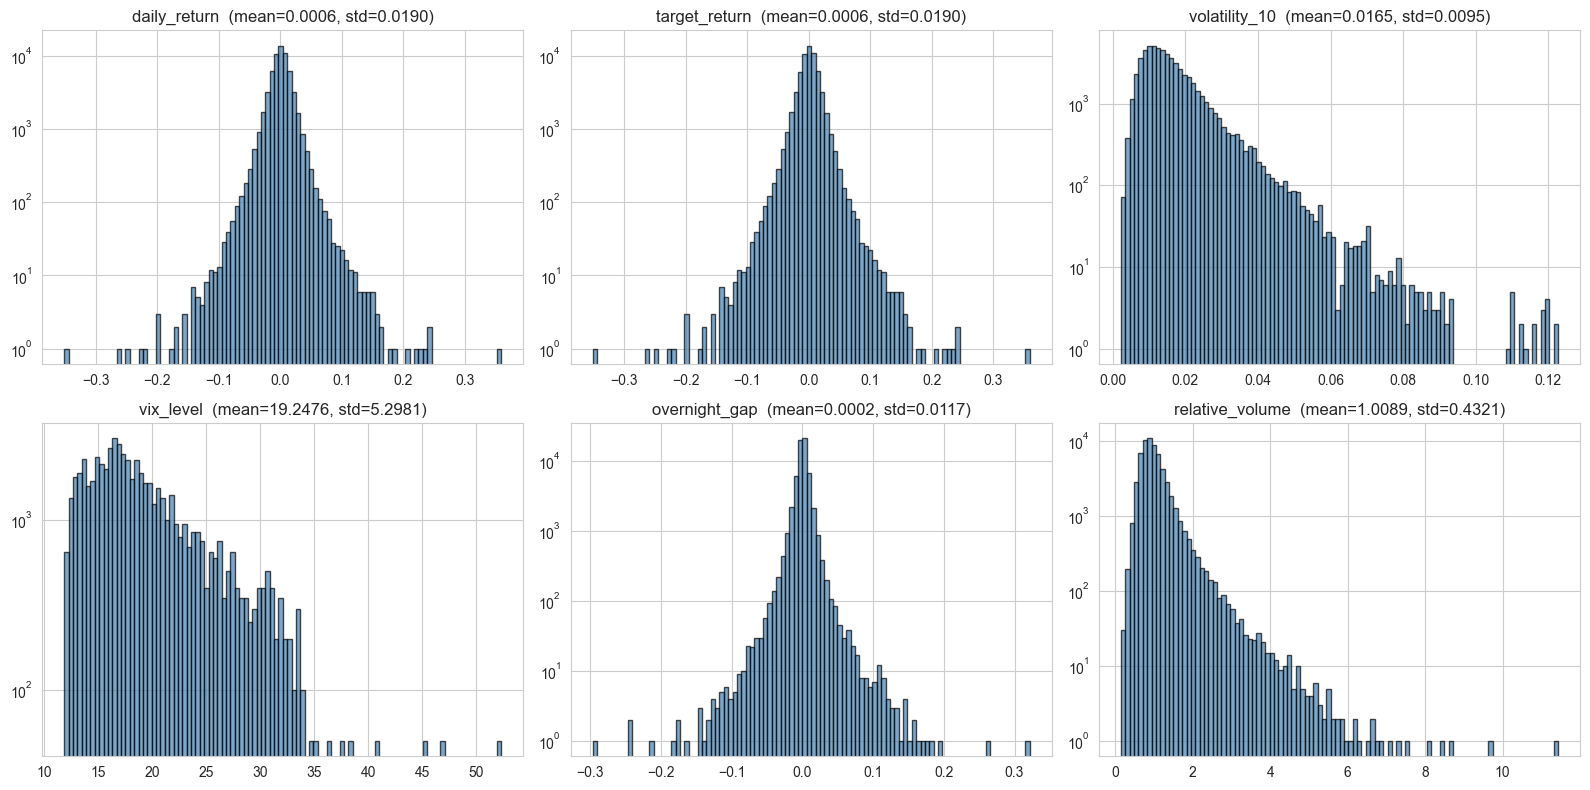

In [26]:
# check 2: feature summary statistics
print("Feature summary stats:")
feature_stats = df_final[FEATURE_COLS].describe().T
print(feature_stats[["mean", "std", "min", "max"]].round(4))

# check 3: visual distributions of key features 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
check_features = ["daily_return", "target_return", "volatility_10",
                   "vix_level", "overnight_gap", "relative_volume"]

for ax, feat in zip(axes.flatten(), check_features):
    df_final[feat].hist(bins=100, ax=ax, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_title(f"{feat}  (mean={df_final[feat].mean():.4f}, std={df_final[feat].std():.4f})")
    ax.set_yscale("log")  # log scale to see tails

plt.tight_layout()
plt.show()

## 7. Save the Dataset

Save to `data/processed/nexttick_dataset_50tickers.csv`. This file is the single source of truth consumed by Phase 2 (classification) and Phase 3 (regression).

In [ ]:
# Create the output directory if it doesn't exist
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "nexttick_dataset_50tickers.csv"
df_final.to_csv(output_file)

print(f"✓ Saved: {output_file}"
print(f"  File size: {output_file.stat().st_size / 1024 / 1024:.1f} MB")

# summary 
print("PHASE 1 COMPLETE - DATASET SUMMARY\n")
print(f"  Total rows:        {len(df_final):>7,}")
print(f"  Total tickers:     {df_final['ticker'].nunique():>7}")
print(f"  Total sectors:     {len(SECTORS):>7}")
print(f"  Date range:        {df_final.index.min().date()} -> {df_final.index.max().date()}")
print(f"  Features:          {len(FEATURE_COLS):>7}")
print(f"  Targets:           target_return (regression), target_direction (classification)")


✓ Saved: ..\data\processed\nexttick_dataset_50tickers.csv
  File size: 30.2 MB
PHASE 1 COMPLETE - DATASET SUMMARY

  Total rows:         61,750
  Total tickers:          50
  Total sectors:           8
  Date range:        2021-05-18 -> 2026-04-17
  Features:               21
  Targets:           target_return (regression), target_direction (classification)
